# Week 12 Task 4.2 - Hybrid Continuous Planning

This notebook recognises the outside maze walls and compares a Task 4.1 grid route with a route through the configured 5 x 5 obstacle course. Continuous collision-free waypoints are used only inside that course.

In [1]:
from pathlib import Path
import sys
import subprocess
import time
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / 'continuous_planner.py').exists():
    HERE = HERE / 'week12' / '4.2'
sys.path.insert(0, str(HERE))
IMAGE = HERE.parent / 'pics' / 'photos.jpg'
OUTPUT = HERE / 'output'
COURSE_ROW = 1
COURSE_COLUMN = 3

In [2]:
command = [
    sys.executable, '-u', str(HERE / 'continuous_planner.py'), str(IMAGE),
    '--output', str(OUTPUT),
    '--course-row', str(COURSE_ROW),
    '--course-column', str(COURSE_COLUMN),
]
log_path = OUTPUT / 'planner.log'
OUTPUT.mkdir(parents=True, exist_ok=True)
already_running = (
    'planner_process' in globals() and planner_process.poll() is None
)
if already_running:
    print(f'Planner is already running in process {planner_process.pid}.')
else:
    planner_started_at = time.time()
    flags = getattr(subprocess, 'CREATE_NEW_PROCESS_GROUP', 0)
    flags |= getattr(subprocess, 'DETACHED_PROCESS', 0)
    with log_path.open('w', encoding='utf-8') as log:
        planner_process = subprocess.Popen(
            command, cwd=HERE, stdout=log, stderr=subprocess.STDOUT,
            creationflags=flags, close_fds=True,
        )
    time.sleep(0.5)
    if planner_process.poll() is None:
        print(f'Planner started in process {planner_process.pid}.')
        print('After the route appears, it remains visible until you press Esc or close the window.')
    else:
        print(log_path.read_text(encoding='utf-8', errors='replace'))

Planner started in process 26148.
After the route appears, it remains visible until you press Esc or close the window.


The route for this run is not ready yet. Complete START and GOAL in the planner window.


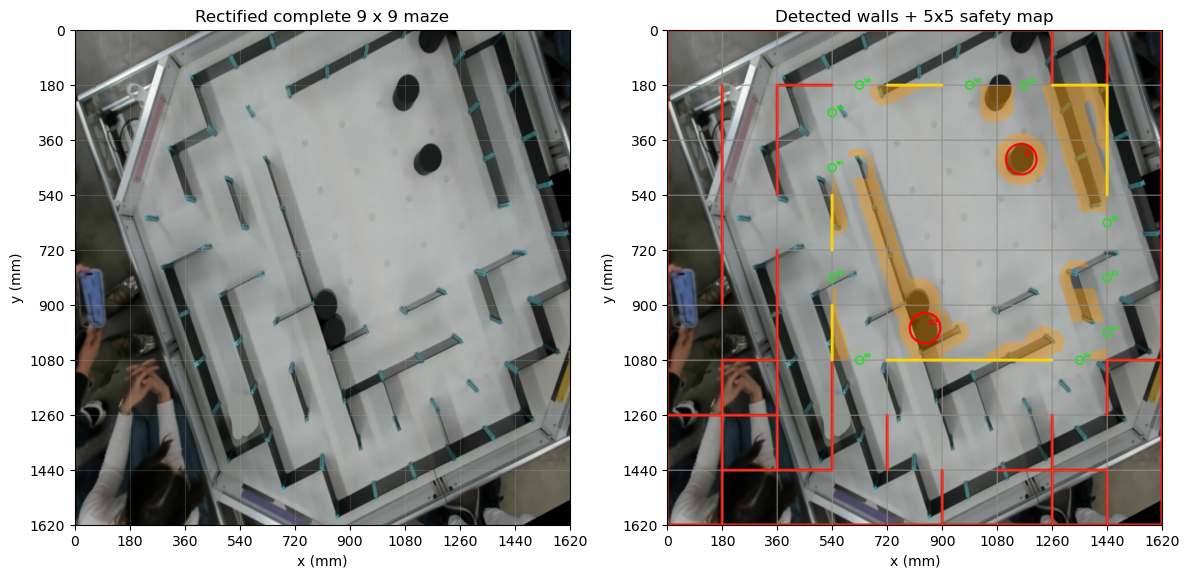

In [3]:
from continuous_planner import read_image
current_run = globals().get('planner_started_at', 0)
route_image = OUTPUT / 'hybrid_planned_route.png'
route_is_current = route_image.exists() and route_image.stat().st_mtime >= current_run
files = [
    ('Rectified complete 9 x 9 maze', OUTPUT / 'rectified_maze.png'),
    ('Detected walls + 5x5 safety map', OUTPUT / 'hybrid_occupancy_map.png'),
    ('Latest complete route', route_image if route_is_current else Path('__waiting__')),
]
available = [(title, path) for title, path in files if path.exists()]
if not route_is_current:
    print('The route for this run is not ready yet. Complete START and GOAL in the planner window.')
if not available:
    print('No planner output yet.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 6))
    axes = [axes] if len(available) == 1 else axes
    for axis, (title, path) in zip(axes, available):
        image = read_image(path)
        axis.imshow(image[:, :, ::-1])
        axis.set_title(title)
        axis.set_xlabel('x (mm)')
        axis.set_ylabel('y (mm)')
        axis.set_xticks(range(0, 1621, 180))
        axis.set_yticks(range(0, 1621, 180))
        axis.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
route_file = OUTPUT / 'route_commands.txt'
if route_is_current and route_file.exists():
    print(route_file.read_text(encoding='utf-8'))

## Run the route on Arduino

The output ends with one `#define GENERATED_ROUTE "BEGIN;...;END;"` line. `G180` is a normal Task 4.1 grid-cell move with lidar wall correction; `F...` is used only inside the 5 x 5 obstacle course. Paste the complete line between the markers in `week12_4_2_waypoint_runner.ino`.

In [4]:
# The independent planner writes the complete GENERATED_ROUTE line to:
print(OUTPUT / 'route_commands.txt')

C:\Users\QwQ\Desktop\work\mtrn3100\week12\4.2\output\route_commands.txt
